<a href="https://colab.research.google.com/github/iarabertopena/active-learning-for-multi-label-streams/blob/main/notebooks/02_active_learning_multi_label_streams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt

### Imports

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import psutil
import time
import os

from capymoa.classifier import (
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
)

from capymoa.evaluation import prequential_evaluation

from capymoa.drift.detectors import ADWIN

from capymoa.stream import NumpyStream
from capymoa.stream import Schema

from IPython.utils import process
from collections import deque
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.metrics import (hamming_loss, f1_score)

### Datasets

In [45]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Flags.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "flags.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags/flags.arff


In [46]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Emotions.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "emotions.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions/emotions.arff


In [47]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Scene.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "scene.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene/scene.arff


In [48]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPGrad.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPInc.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/"

dataset_paths = {
    "flags": base_path + "flags/flags.arff",
    "emotions": base_path + "emotions/emotions.arff",
    "scene": base_path + "scene/scene.arff",
    #"synhpgrad": base_path + "SynHPGrad.arff",
    #"synhpinc": base_path + "SynHPInc.arff"
}

n_labels_dict = {
    "flags": 7,
    "emotions": 6,
    "scene": 6,
    #"synhpgrad": 8,
    #"synhpinc": 8
}

In [51]:
def load_multilabel_dataset(dataset_name):

    dataset_path = dataset_paths[dataset_name]

    n_labels = n_labels_dict[dataset_name]

    # carregar arff
    data, meta = arff.loadarff(dataset_path)

    # dataframe
    df = pd.DataFrame(data)

    # converter bytes -> string/int
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode('utf-8')
                if isinstance(x, bytes)
                else x
            )

    # converter tudo para float
    df = df.astype(float)

    # dataset sintéticos: labels no começo
    if dataset_name in ["synhpgrad", "synhpinc"]:

        Y = df.iloc[:, :n_labels].values.astype(int)

        X = df.iloc[:, n_labels:].values

    # datasets reais: labels no final
    else:

        X = df.iloc[:, :-n_labels].values

        Y = df.iloc[:, -n_labels:].values.astype(int)

    return X, Y

### Métricas de avaliação

In [52]:
# métricas
metrics = {
    "f1": "Macro-F1",
    "hamming": "Hamming Loss",
    "exact_match": "Exact Match"
}

### Binary Relevance

In [53]:
class BinaryRelevance:

    def __init__(self, model_class, n_labels, schema):

        self.n_labels = n_labels
        self.models = []

        for _ in range(n_labels):

            model = model_class(
                schema=schema
            )

            self.models.append(model)

    # previsão
    def predict(self, x):

        predictions = []

        temp_stream = NumpyStream(
             X=np.array([x]),
             y=np.array([0])
          )

        instance = temp_stream.next_instance()

        for model in self.models:

            pred = model.predict(instance)

            if pred is None:
                pred = 0

            predictions.append(int(pred))

        return np.array(predictions)

    # probabilidades
    def predict_proba(self, x):

        probabilities = []

        temp_stream = NumpyStream(
            X=np.array([x]),
            y=np.array([0])
        )

        instance = temp_stream.next_instance()

        for model in self.models:

            proba = model.predict_proba(instance)

            if proba is None:
                proba = np.array([0.5, 0.5])

            probabilities.append(proba)

        return probabilities

    # treino
    def train(self, x, y, label_mask=None):

        # se não tem máscara, assume que todos os rótulos estão disponíveis
        if label_mask is None:
            label_mask = [True] * self.n_labels

        if len(label_mask) != self.n_labels:
            raise ValueError("label_mask deve ter tamanho n_labels")

        for j, model in enumerate(self.models):

            # treina apenas os rótulos observados
            if label_mask[j]:

              temp_stream = NumpyStream(
                  X=np.array([x]),
                  y=np.array([y[j]])
              )

              instance = temp_stream.next_instance()

              model.train(instance)

### Active Learning

In [54]:
class ActiveLearningStrategy:

    def __init__(self):

        self.total_seen = 0
        self.total_queried = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):
        raise NotImplementedError

#### Random

In [55]:
class RandomSampling(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        if np.random.rand() < self.budget:

            self.total_queried += 1

            return True

        return False

#### Uncertainty sampling

In [56]:
def compute_uncertainty(probabilities):
    uncertainties = []

    for proba in probabilities:
        # Least Confidence
        confidence = np.max(proba)
        uncertainty = 1 - confidence
        uncertainties.append(uncertainty)

    #result = np.mean(uncertainties)
    result = np.max(uncertainties)

    return result

In [57]:
class UncertaintySampling(ActiveLearningStrategy):

    def __init__(self, threshold, budget):

        super().__init__()

        self.threshold = threshold
        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        #print(probabilities)
        uncertainty = compute_uncertainty(probabilities)

        if uncertainty >= self.threshold:

            self.total_queried += 1

            return True

        return False

#### Query-by-committee

In [58]:
committee_models = [
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
]

In [59]:
class Committee:

    def __init__(self, model_classes, n_labels, schema):

        self.models = []

        for model_class in model_classes:

            br_model = BinaryRelevance(
                model_class=model_class,
                n_labels=n_labels,
                schema=schema
            )

            self.models.append(br_model)

    def predict_all(self, x):

        predictions = []

        for model in self.models:

            predictions.append(
                model.predict(x)
            )

        return np.array(predictions)

    def predict_proba_all(self, x):

        probabilities = []

        for model in self.models:

            probabilities.append(
                model.predict_proba(x)
            )

        return probabilities

    def train(self, x, y, label_mask=None):

        for model in self.models:

            model.train(x, y, label_mask=label_mask)

In [60]:
def compute_vote_entropy(predictions):

    entropies = []

    n_members = predictions.shape[0]

    for label in range(predictions.shape[1]):

        votes = predictions[:, label]

        counts = np.bincount(
            votes,
            minlength=2
        )

        probs = counts / n_members

        probs = probs[probs > 0]

        entropy = -np.sum(
            probs * np.log2(probs)
        )

        entropies.append(entropy)

    return np.mean(entropies)

In [61]:
class QueryByCommittee(ActiveLearningStrategy):

    def __init__(self, threshold, budget, warmup):

        super().__init__()

        self.threshold = threshold
        self.budget = budget
        self.warmup = warmup

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        # warm-up
        if self.total_seen <= self.warmup:

            self.total_queried += 1
            return True

        if committee_predictions is None:
            return False

        disagreement = compute_vote_entropy(committee_predictions)

        #print(f"Seen={self.total_seen} | "f"Disagreement={disagreement:.4f}")

        if disagreement >= self.threshold:

            self.total_queried += 1
            return True

        return False

#### Bounds

##### Lower Bound -> sem consultas (budget = 0%)

In [62]:
class NoQuery(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        return False

##### Upper Bound -> aprendizado totalmente supervisionado (budget = 100%)

In [63]:
class FullSupervision(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 1.0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1
        self.total_queried += 1

        return True

### Loop principal

In [64]:
def run_experiment(dataset_name, strategy, model_class):

    print(f"Dataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    # split (para teste inicial)
    X_train, X_stream, Y_train, Y_stream = train_test_split(
        X,
        Y,
        test_size=0.70,
        shuffle=False
    )

    print(
        f"Train: {len(X_train)} | "
        f"Stream: {len(X_stream)}"
    )

    n = len(X_stream)

    strategy.budget_limit = int(strategy.budget * n)
    print(
        f"Budget limit: {strategy.budget_limit}"
    )

    # checkpoints em %
    checkpoints = [
        max(1, round(n * pct / 100))
        for pct in range(10, 101, 10)
    ]

    strategy.total_seen = 0
    strategy.total_queried = 0

    # schema
    dummy_X = np.zeros((1, X.shape[1]))
    dummy_y = np.zeros(1)

    stream = NumpyStream(
        X=dummy_X,
        y=dummy_y
    )

    schema = stream.get_schema()

    # modelo principal
    model = BinaryRelevance(
        model_class=model_class,
        n_labels=Y.shape[1],
        schema=schema
    )

    # detector de drift
    adwin = ADWIN()

    drift_points = []

    # comitê para QBC
    committee = Committee(
        model_classes=committee_models,
        n_labels=Y.shape[1],
        schema=schema
    )

    # treinamento inicial (30% do dataset)
    for i in range(len(X_train)):
        model.train(
            X_train[i],
            Y_train[i]
        )

        committee.train(
            X_train[i],
            Y_train[i]
        )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # histórico opara gráficos
    history = {
        "progress": [],
        "hamming": [],
        "exact_match": [],
        "f1": [],
        "queries": [],
        "evaluated": []
    }

    # loop prequential (70% do dataset)
    for i in range(len(X_stream)):
        x = X_stream[i]
        y = Y_stream[i]

        # previsão do modelo principal
        y_pred = model.predict(x)

        # probabilidades do modelo principal
        probs = model.predict_proba(x)

        # previsões do comitê
        committee_predictions = None

        if isinstance(strategy, QueryByCommittee):
            committee_predictions = committee.predict_all(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(np.array_equal(y, y_pred))

        f1 = f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )

        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # detector de drift
        adwin.add_element(ham)

        if adwin.detected_change():
            drift_points.append(i)

        # salvar histórico nos checkpoints
        if (i + 1) in checkpoints:
            history["progress"].append(round(100 * (i + 1) / n))

            if len(hamming_scores) > 0:
                history["hamming"].append(np.mean(hamming_scores))
                history["exact_match"].append(np.mean(exact_match_scores))
                history["f1"].append(np.mean(f1_scores))

            else:
                history["hamming"].append(np.nan)
                history["exact_match"].append(np.nan)
                history["f1"].append(np.nan)

            history["queries"].append(strategy.total_queried)
            history["evaluated"].append(len(hamming_scores))

        # Active Learning
        queried = strategy.query(
            x=x,
            y_pred=y_pred,
            probabilities=probs,
            committee_predictions=committee_predictions,
            committee_probabilities=None
        )

        if queried:
            # treina modelo principal
            model.train(x, y)

            # treina todos os membros do comitê
            committee.train(x, y)

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2

    memory_usage = max(
        0,
        memory_after - memory_before
    )

    # consultas por segundo
    queries_per_second = (
        strategy.total_queried / execution_time
        if execution_time > 0
        else 0
    )

    # proporção de instâncias consultadas
    query_rate = (
        strategy.total_queried / strategy.total_seen
        if strategy.total_seen > 0
        else 0
    )

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage,
      "Queried Instances": strategy.total_queried,
      "Queries per Second": queries_per_second,
      "Query Rate": query_rate,
      "Drift Points": drift_points,
      "Number of Drifts": len(drift_points),
      "History": history
  }

    print(results)

    return results

In [65]:
strategies = {
    "NoQuery": NoQuery(),
    "Random": RandomSampling(budget=0.10),
    "Uncertainty": UncertaintySampling(threshold=0.30, budget=0.10),
    "QBC": QueryByCommittee(threshold=0.30, budget=0.10, warmup=0),
    "FullSupervision": FullSupervision()
}

for strategy_name, strategy in strategies.items():

    print(f"\nStrategy: {strategy_name}")

    results = run_experiment("flags", strategy, model_class=AdaptiveRandomForestClassifier)


Strategy: NoQuery
Dataset: flags
Train: 58 | Stream: 136
Budget limit: 0
{'Hamming Loss': np.float64(0.3161764705882352), 'Exact Match': np.float64(0.08823529411764706), 'F1-score': np.float64(0.659499140565317), 'Execution Time (s)': 0.8674757480621338, 'Memory Usage (MB)': 0, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.336734693877551), np.float64(0.30687830687830686), np.float64(0.3414634146341463), np.float64(0.3465608465608465), np.float64(0.33193277310924363), np.float64(0.3205574912891985), np.float64(0.3203007518796991), np.float64(0.3211009174311927), np.float64(0.3208430913348946), np.float64(0.3161764705882352)], 'exact_match': [np.float64(0.07142857142857142), np.float64(0.1111111111111111), np.float64(0.07317073170731707), np.float64(0.05555555555555555), np.float64(0.08823529411764706), np.float64(0.0975609756097

### Rodando os 5 datasets

In [66]:
all_results = {}

strategies = {
    "NoQuery": NoQuery(),
    "Random": RandomSampling(budget=0.10),
    "Uncertainty": UncertaintySampling(threshold=0.30, budget=0.10),
    "QBC": QueryByCommittee(threshold=0.30, budget=0.10, warmup=10),
    "FullSupervision": FullSupervision()
}

for dataset_name in dataset_paths.keys():

    all_results[dataset_name] = {}

    for strategy_name, strategy in strategies.items():

        print(f"\nStrategy: {strategy_name}")

        results = run_experiment(dataset_name, strategy, model_class=AdaptiveRandomForestClassifier)

        all_results[dataset_name][strategy_name] = results


Strategy: NoQuery
Dataset: flags
Train: 58 | Stream: 136
Budget limit: 0
{'Hamming Loss': np.float64(0.3161764705882352), 'Exact Match': np.float64(0.08823529411764706), 'F1-score': np.float64(0.659499140565317), 'Execution Time (s)': 1.070329189300537, 'Memory Usage (MB)': 0, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.336734693877551), np.float64(0.30687830687830686), np.float64(0.3414634146341463), np.float64(0.3465608465608465), np.float64(0.33193277310924363), np.float64(0.3205574912891985), np.float64(0.3203007518796991), np.float64(0.3211009174311927), np.float64(0.3208430913348946), np.float64(0.3161764705882352)], 'exact_match': [np.float64(0.07142857142857142), np.float64(0.1111111111111111), np.float64(0.07317073170731707), np.float64(0.05555555555555555), np.float64(0.08823529411764706), np.float64(0.09756097560975

### Resultados

In [67]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Hamming Loss": results["Hamming Loss"],
            "Exact Match": results["Exact Match"],
            "F1-score": results["F1-score"],
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"],
            "Queried Instances": results["Queried Instances"],
            "Queries per Second": results["Queries per Second"],
            "Query Rate": results["Query Rate"]

        })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset         Strategy  Hamming Loss  Exact Match  F1-score  \
0      flags          NoQuery      0.316176     0.088235  0.659499   
1      flags           Random      0.309874     0.102941  0.666504   
2      flags      Uncertainty      0.305672     0.102941  0.668124   
3      flags              QBC      0.311975     0.073529  0.662555   
4      flags  FullSupervision      0.282563     0.080882  0.690560   
5   emotions          NoQuery      0.258413     0.137019  0.632367   
6   emotions           Random      0.253606     0.153846  0.640838   
7   emotions      Uncertainty      0.255609     0.146635  0.622292   
8   emotions              QBC      0.240385     0.168269  0.651710   
9   emotions  FullSupervision      0.218349     0.230769  0.680404   
10     scene          NoQuery      0.272700     0.120475  0.495712   
11     scene           Random      0.171316     0.226113  0.586459   
12     scene      Uncertainty      0.209496     0.255193  0.571512   
13     scene        

flags


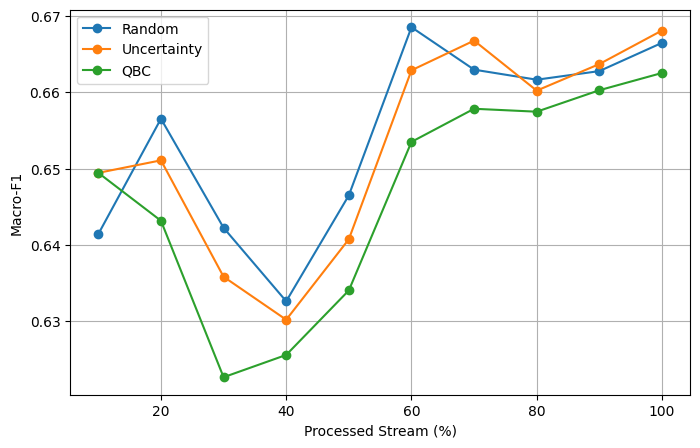

emotions


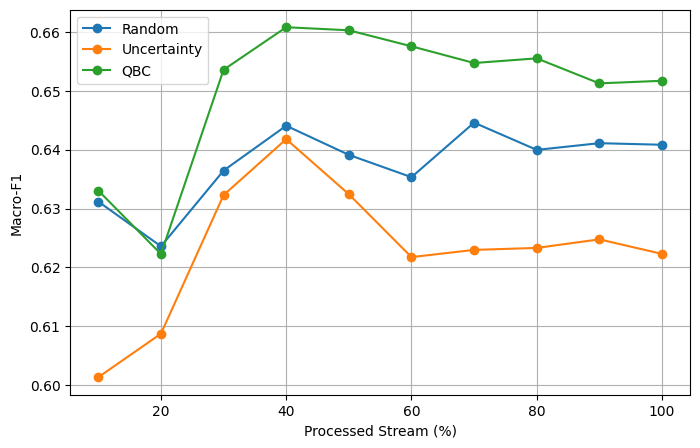

scene


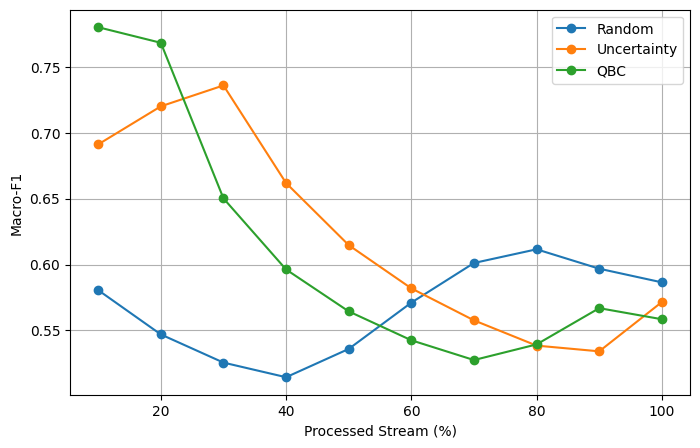

In [68]:
for dataset_name in all_results.keys():

    print(dataset_name)

    plt.figure(figsize=(8,5))

    for strategy in ["Random", "Uncertainty", "QBC"]:

        hist = all_results[dataset_name][strategy]["History"]

        plt.plot(
            hist["progress"],
            hist["f1"],
            marker="o",
            label=strategy
        )

    plt.xlabel("Processed Stream (%)")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(True)

    plt.show()

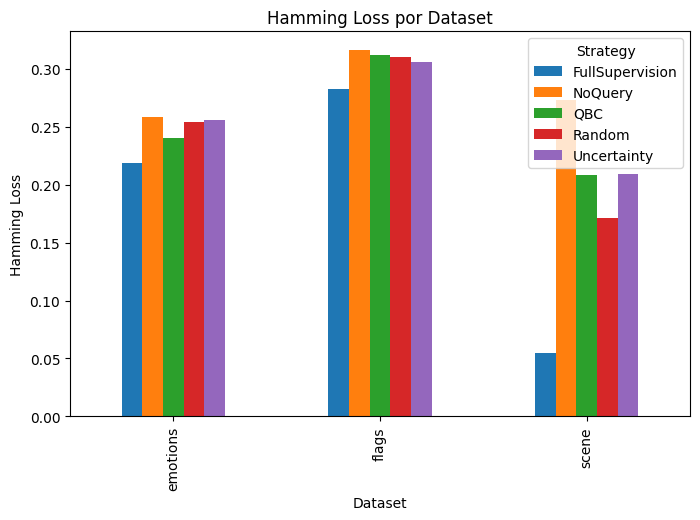

In [69]:
pivot_f1 = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Hamming Loss"
)

pivot_f1.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Hamming Loss")
plt.title("Hamming Loss por Dataset")
plt.show()

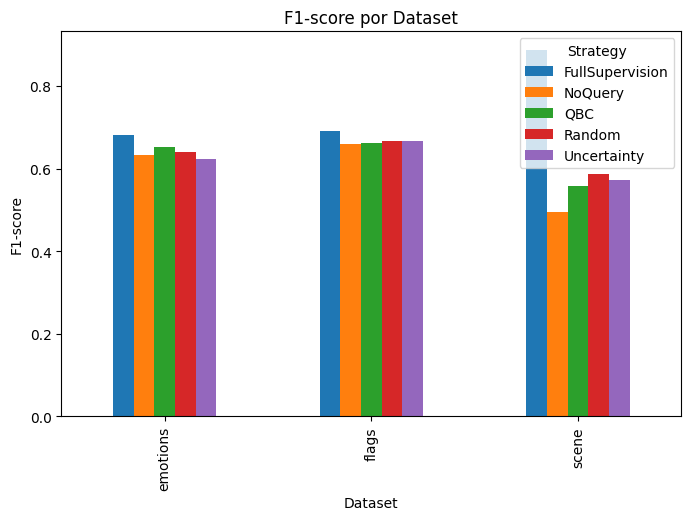

In [70]:
pivot_f1 = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="F1-score"
)

pivot_f1.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("F1-score")
plt.title("F1-score por Dataset")
plt.show()

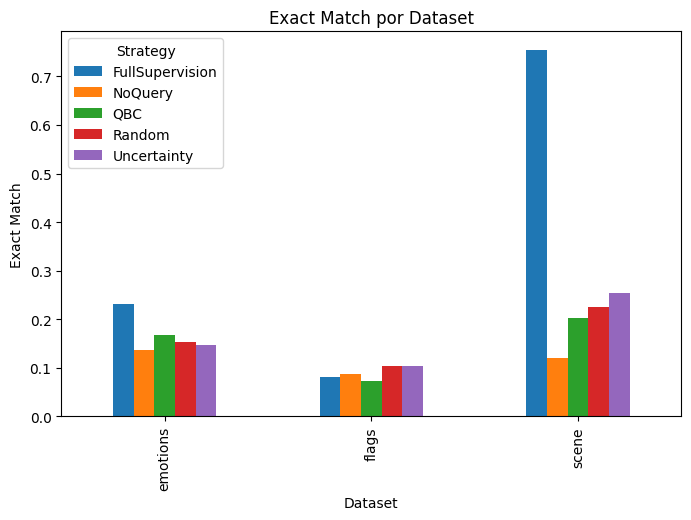

In [71]:
pivot_f1 = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Exact Match"
)

pivot_f1.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Exact Match")
plt.title("Exact Match por Dataset")
plt.show()

### Análise de drift com ADWIN

In [72]:
for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        print(f"\nStrategy: {strategy_name}")
        print(f"Dataset: {dataset_name} -> Drifts detectados:", results["Number of Drifts"])


Strategy: NoQuery
Dataset: flags -> Drifts detectados: 0

Strategy: Random
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty
Dataset: flags -> Drifts detectados: 0

Strategy: QBC
Dataset: flags -> Drifts detectados: 0

Strategy: FullSupervision
Dataset: flags -> Drifts detectados: 0

Strategy: NoQuery
Dataset: emotions -> Drifts detectados: 0

Strategy: Random
Dataset: emotions -> Drifts detectados: 0

Strategy: Uncertainty
Dataset: emotions -> Drifts detectados: 0

Strategy: QBC
Dataset: emotions -> Drifts detectados: 0

Strategy: FullSupervision
Dataset: emotions -> Drifts detectados: 0

Strategy: NoQuery
Dataset: scene -> Drifts detectados: 3

Strategy: Random
Dataset: scene -> Drifts detectados: 2

Strategy: Uncertainty
Dataset: scene -> Drifts detectados: 4

Strategy: QBC
Dataset: scene -> Drifts detectados: 3

Strategy: FullSupervision
Dataset: scene -> Drifts detectados: 0


### Análise de consumo de memória e tempo de execução

In [73]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"]
        })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset         Strategy  Execution Time (s)  Memory Usage (MB)
0      flags          NoQuery            1.070329           0.000000
1      flags           Random            4.816019         872.152344
2      flags      Uncertainty            2.083044           0.031250
3      flags              QBC            3.261956           0.000000
4      flags  FullSupervision           21.804421           0.230469
5   emotions          NoQuery            5.970509           0.000000
6   emotions           Random           21.980095           0.042969
7   emotions      Uncertainty           21.157566           0.000000
8   emotions              QBC           27.968160           0.000000
9   emotions  FullSupervision          134.496790         110.542969
10     scene          NoQuery           65.686479           0.007812
11     scene           Random          254.874276          38.570312
12     scene      Uncertainty          187.789488           0.074219
13     scene              QBC     

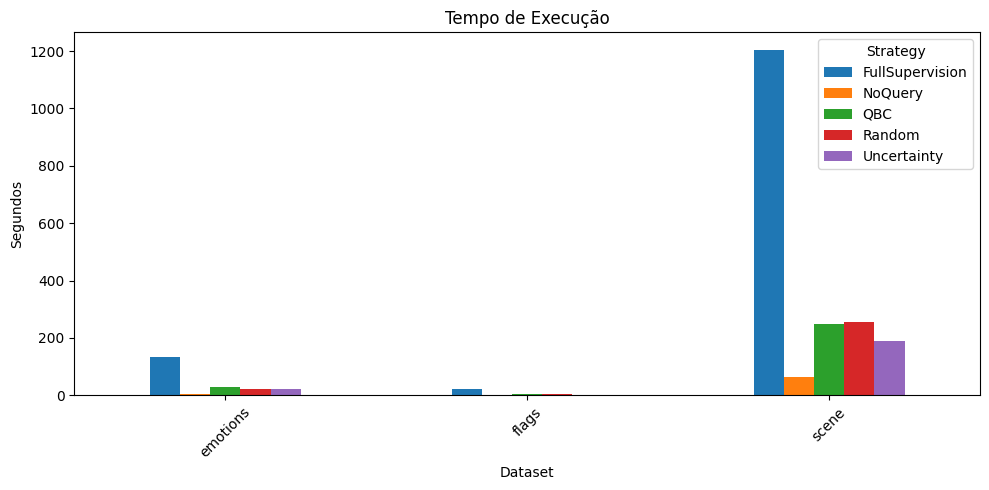

In [74]:
pivot_time = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Execution Time (s)"
)

pivot_time.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Tempo de Execução")
plt.ylabel("Segundos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

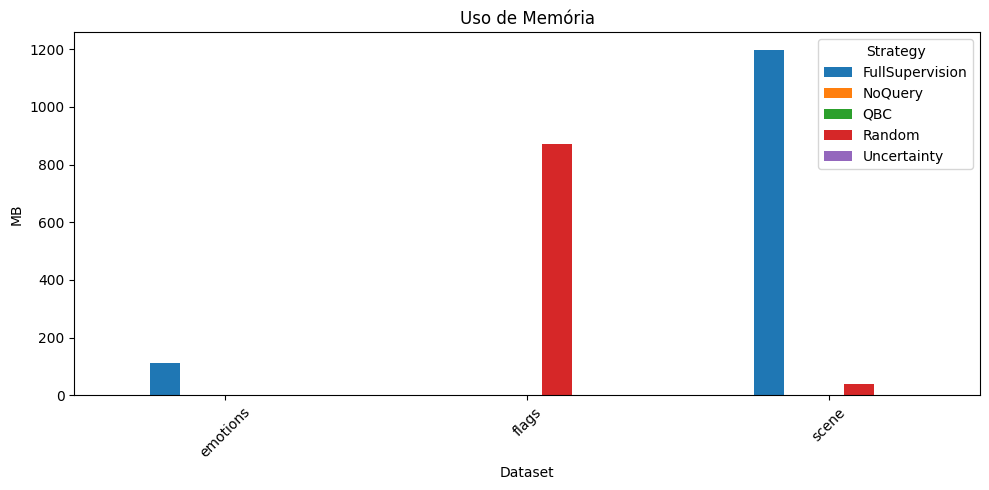

In [75]:
pivot_memory = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Memory Usage (MB)"
)

pivot_memory.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Uso de Memória")
plt.ylabel("MB")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()